NAME:Vishveshwari Yuvraj Patil

Roll No:42

DIV:B

PRN:2324000875

Experiment 3

Image Enhancement using
Histogram Equalization

In [1]:
import cv2
import numpy as np

In [13]:
from google.colab import drive
from google.colab import files
upload = files.upload()

Saving adorable-cat-lifestyle.jpg to adorable-cat-lifestyle.jpg


In [29]:
img= cv2.imread('adorable-cat-lifestyle.jpg', cv2.IMREAD_GRAYSCALE)

In [30]:
img

array([[209, 209, 209, ..., 194, 194, 194],
       [209, 209, 209, ..., 194, 194, 194],
       [209, 209, 209, ..., 194, 194, 194],
       ...,
       [195, 195, 195, ..., 233, 233, 233],
       [195, 195, 195, ..., 233, 233, 233],
       [195, 195, 195, ..., 233, 233, 233]], dtype=uint8)

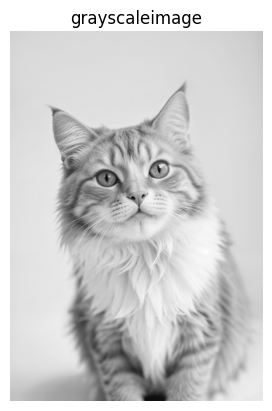

In [32]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')
plt.title('grayscaleimage')
plt.axis('off')
plt.show()

In [33]:
height,width = img.shape
total_pixels = height*width
print(total_pixels)

16187392


In [34]:
hist = np.zeros(256,dtype=int)

In [35]:
for row in img:
  for pixel_value in row:
    hist[pixel_value] += 1

In [36]:
hist,_=np.histogram(img.flatten(),256,[0,256])

In [37]:
hist_normalised = hist/total_pixels

In [39]:
hist_normalized

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.23552948e-07,
       1.05020006e-06, 4.38612965e-06, 1.35908243e-05, 2.54519073e-05,
       4.02782610e-05, 5.41779676e-05, 6.43710858e-05, 7.28962392e-05,
       8.35835692e-05, 9.48268875e-05, 1.13545159e-04, 1.38688184e-04,
       1.72356362e-04, 4.86489732e-04, 6.76575943e-04, 8.32623316e-04,
       9.45180051e-04, 1.06162870e-03, 1.15268723e-03, 1.20667987e-03,
       1.25183847e-03, 1.29810905e-03, 1.34703601e-03, 1.39157685e-03,
       1.44594015e-03, 1.50302161e-03, 1.56541585e-03, 1.62305330e-03,
       1.68192628e-03, 1.74481473e-03, 1.80690009e-03, 1.86534063e-03,
       1.92489315e-03, 1.98759627e-03, 2.04554261e-03, 2.10027656e-03,
       2.15204525e-03, 2.21023868e-03, 2.27491865e-03, 2.35207747e-03,
       2.42349107e-03, 2.50577734e-03, 2.58831071e-03, 2.67930745e-03,
       2.77938534e-03, 2.88452890e-03, 3.02019003e-03, 3.19192863e-03,
       3.36805336e-03, 3.51230143e-03, 3.65494330e-03, 3.79727630e-03,
      

In [40]:
cdf = np.cumsum(hist_normalised)

In [41]:
new_value = np.round(255 * cdf).astype('uint8')

In [42]:
img_equalized = new_value[img]

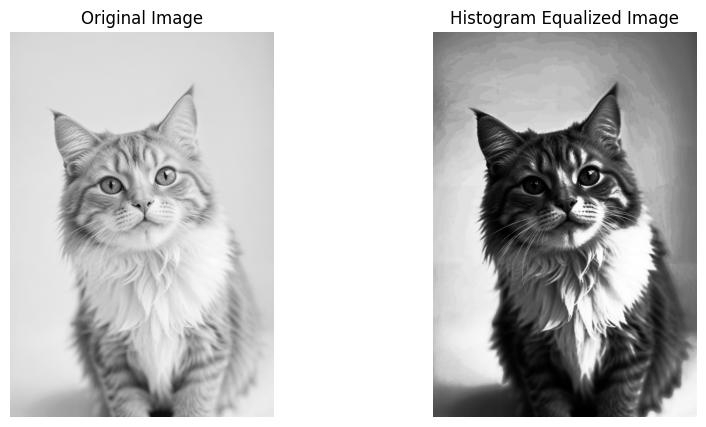

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image') # Added title for clarity
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(img_equalized,cmap='gray')
plt.title('Histogram Equalized Image') # Added title for clarity
plt.axis('off')
plt.show()

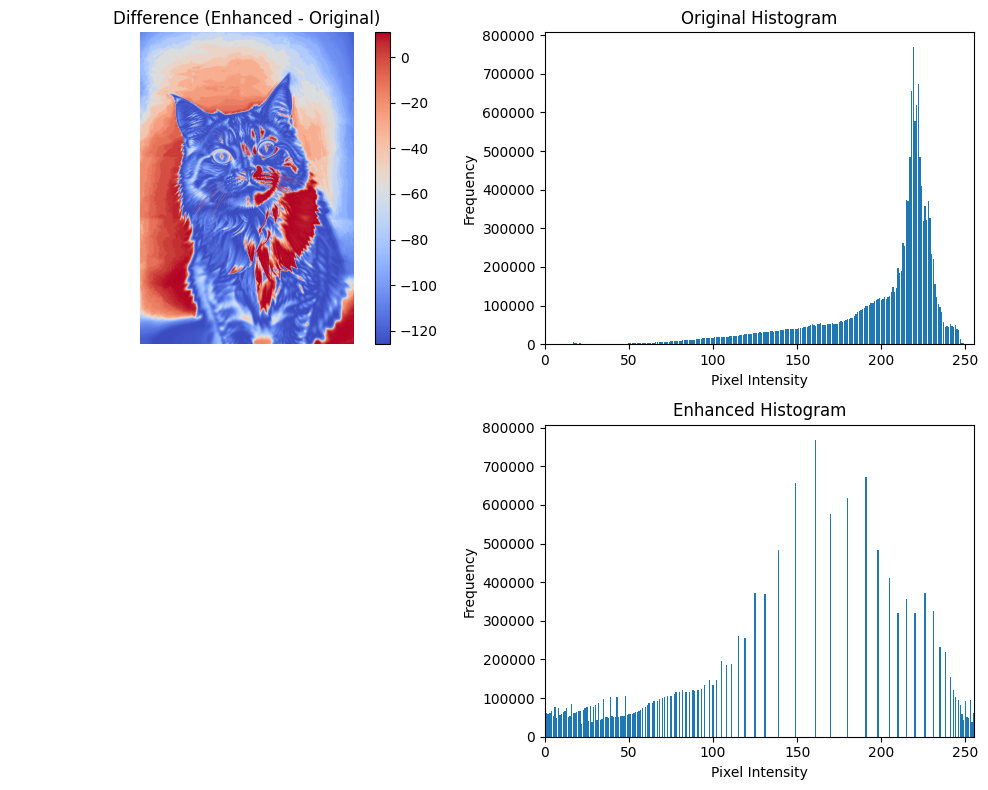

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # Create a new figure with a 2x2 grid of subplots

axes[0, 1].bar(range(256), hist)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim([0, 255])

# Calculate and plot enhanced histogram
enhanced_hist, _ = np.histogram(img_equalized.flatten(), 256, [0, 256])
axes[1, 1].bar(range(256), enhanced_hist)
axes[1, 1].set_title('Enhanced Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim([0, 255])

# Calculate and plot difference image on axes[0, 0]
diff = img_equalized.astype(int) - img.astype(int)
im_diff = axes[0, 0].imshow(diff, cmap='coolwarm')
axes[0, 0].set_title('Difference (Enhanced - Original)')
axes[0, 0].axis('off')
fig.colorbar(im_diff, ax=axes[0, 0]) # Attach colorbar to the figure, specifying the axis

# Clear axes[1,0] if not needed
axes[1, 0].axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

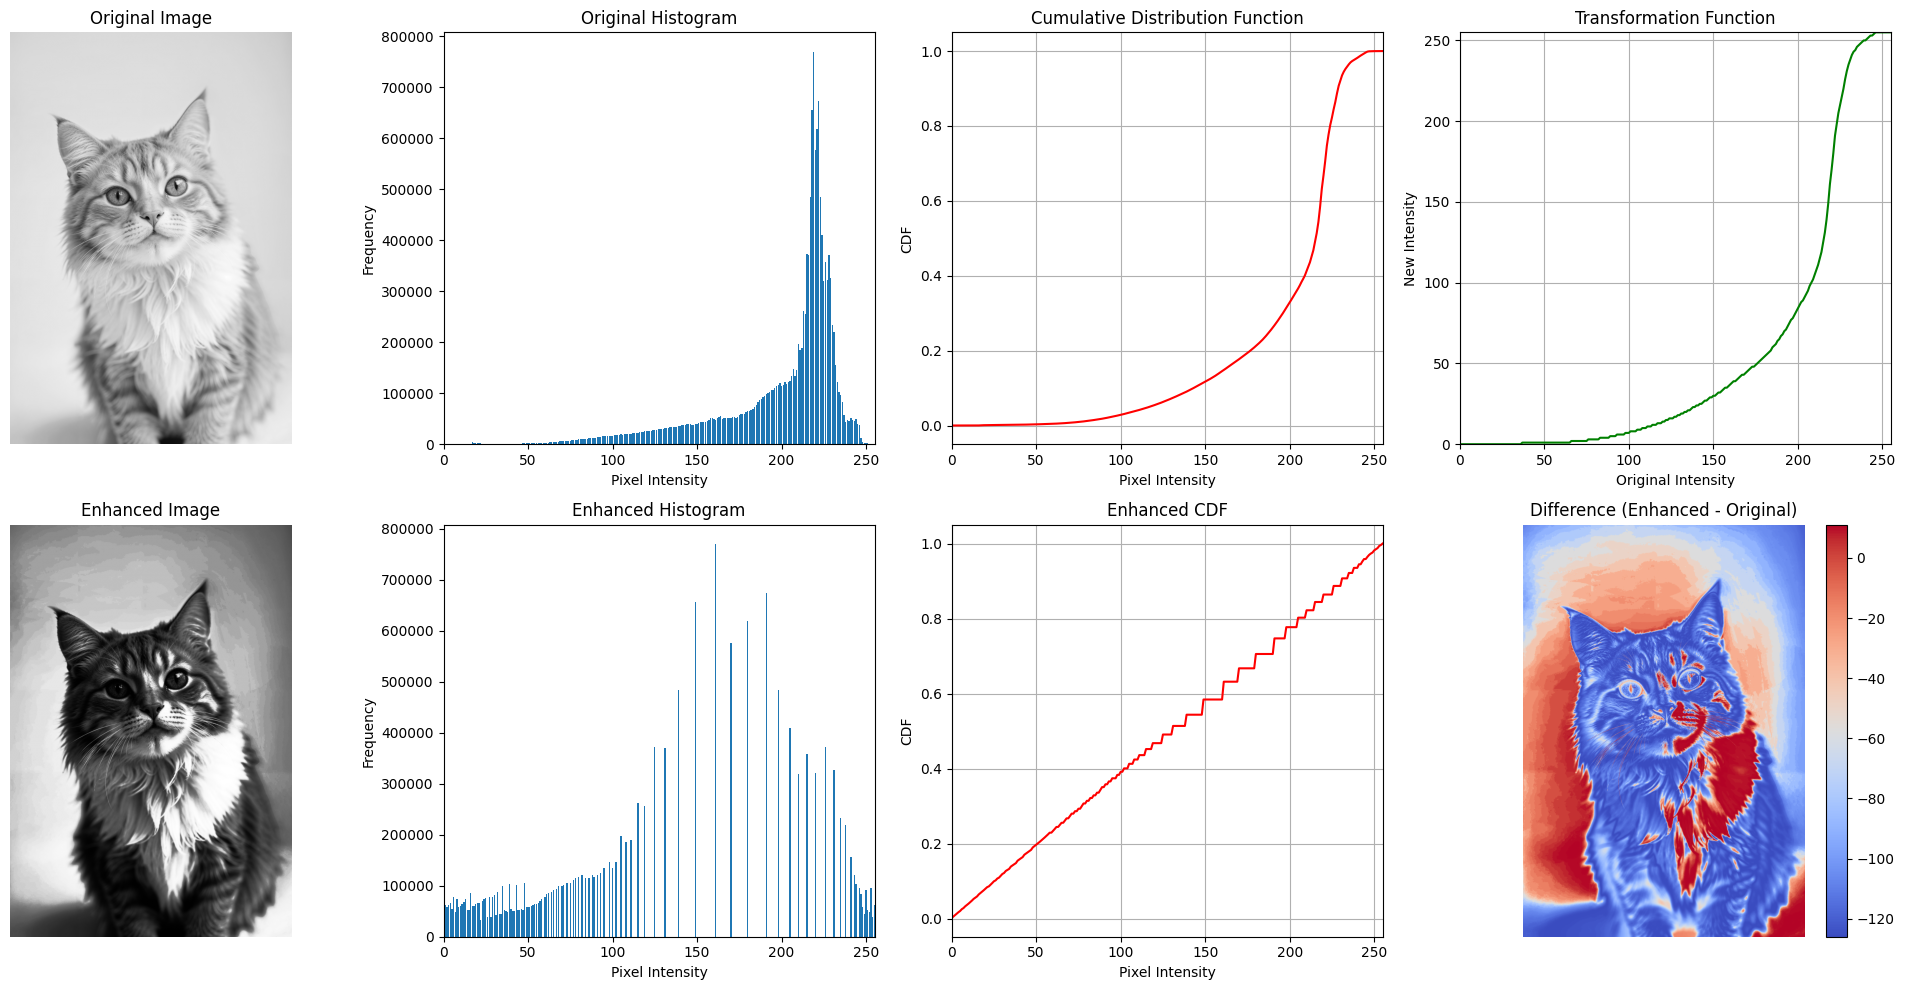

In [58]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) # Create a new figure with a 2x4 grid of subplots

# Original Image
axes[0, 0].imshow(img, cmap='gray') # Use img instead of original
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Original Histogram
axes[0, 1].bar(range(256), hist)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim([0, 255])

# Original CDF
axes[0, 2].plot(range(256), cdf, 'r-')
axes[0, 2].set_title('Cumulative Distribution Function')
axes[0, 2].set_xlabel('Pixel Intensity')
axes[0, 2].set_ylabel('CDF')
axes[0, 2].set_xlim([0, 255])
axes[0, 2].grid(True)

# Transformation Function
axes[0, 3].plot(range(256), new_value, 'g-')
axes[0, 3].set_title('Transformation Function')
axes[0, 3].set_xlabel('Original Intensity')
axes[0, 3].set_ylabel('New Intensity')
axes[0, 3].set_xlim([0, 255])
axes[0, 3].set_ylim([0, 255])
axes[0, 3].grid(True)

# Enhanced Image
axes[1, 0].imshow(img_equalized, cmap='gray') # Use img_equalized instead of enhanced_img
axes[1, 0].set_title('Enhanced Image')
axes[1, 0].axis('off')

# Enhanced Histogram
enhanced_hist, _ = np.histogram(img_equalized.flatten(), 256, [0, 256]) # Use img_equalized
axes[1, 1].bar(range(256), enhanced_hist)
axes[1, 1].set_title('Enhanced Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim([0, 255])

# Enhanced CDF
enhanced_cdf = np.cumsum(enhanced_hist) / np.sum(enhanced_hist)
axes[1, 2].plot(range(256), enhanced_cdf, 'r-')
axes[1, 2].set_title('Enhanced CDF')
axes[1, 2].set_xlabel('Pixel Intensity')
axes[1, 2].set_ylabel('CDF')
axes[1, 2].set_xlim([0, 255])
axes[1, 2].grid(True)

# Difference Image
diff = img_equalized.astype(int) - img.astype(int) # Use img_equalized and img
im_diff = axes[1, 3].imshow(diff, cmap='coolwarm')
axes[1, 3].set_title('Difference (Enhanced - Original)')
axes[1, 3].axis('off')
plt.colorbar(im_diff, ax=axes[1, 3])

plt.tight_layout()
plt.show()